# 01 - Carga y revision inicial del dataset

En este notebook se realiza la primera exploracion del dataset de prediccion de inundaciones. El objetivo es cargar los datos, revisar su estructura, comprobar la calidad del dataset e identificar la variable objetivo `FloodProbability`.

Esta primera revision servira como base para el analisis exploratorio visual y para preparar posteriormente el preprocesamiento y el modelado.


In [36]:
from pathlib import Path
import pandas as pd
import os

# Buscar el repo: sube hasta encontrar "data/raw/train.csv"
p = Path.cwd().resolve()
DATA_PATH = None

for parent in [p] + list(p.parents):
    candidate = parent / "data" / "raw" / "train.csv"
    if candidate.exists():
        DATA_PATH = candidate
        break

if DATA_PATH is None:
    raise FileNotFoundError("No se encontró data/raw/train.csv en ningún nivel hacia arriba desde CWD")

print("CWD:", os.getcwd())
print("DATA_PATH:", DATA_PATH)
print("Existe:", DATA_PATH.exists())

os.chdir(str(DATA_PATH.parent))
df = pd.read_csv(str(DATA_PATH))



CWD: C:\Users\Personal\Proyecto-4--Grupo-1\data\raw
DATA_PATH: C:\Users\Personal\Proyecto-4--Grupo-1\data\raw\train.csv
Existe: True


In [37]:
df.head()


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


In [38]:
df.tail()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
1117952,1117952,3,3,4,10,4,5,5,7,10,...,7,8,7,2,2,1,4,6,4,0.495
1117953,1117953,2,2,4,3,9,5,8,1,3,...,9,4,4,3,7,4,9,4,5,0.480
1117954,1117954,7,3,9,4,6,5,9,1,3,...,5,5,5,5,6,5,5,2,4,0.485
1117955,1117955,7,3,3,7,5,2,3,4,6,...,6,8,5,3,4,6,7,6,4,0.495
1117956,1117956,4,5,6,9,5,5,2,8,4,...,4,8,6,5,5,6,7,7,8,0.560


Se revisan tambien las ultimas filas para comprobar que el archivo se ha cargado de forma completa y que no aparecen registros incompletos al final del dataset.

El dataset se ha cargado correctamente. En las primeras filas se observan las variables predictoras y la variable objetivo `FloodProbability`.


In [39]:
df.shape

(1117957, 22)

La celda anterior muestra el numero de filas y columnas del dataset cargado. Este valor debe comprobarse despues de colocar el archivo `train.csv` definitivo en `data/raw/`, ya que cargar un archivo incompleto o ubicado en otra carpeta podria alterar el resultado.



In [40]:
df.columns

Index(['id', 'MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'FloodProbability'],
      dtype='str')

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  IneffectiveDisasterPreparedness  1117957 non-null  int64  
 1

In [42]:
target = "FloodProbability"

if target in df.columns:
    print(f"Variable objetivo encontrada: {target}")
else:
    raise ValueError(f"No se encontro la variable objetivo {target} en el dataset")


Variable objetivo encontrada: FloodProbability


In [43]:
X = df.drop(columns=[target])
y = df[target]

print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

Variables predictoras: (1117957, 21)
Variable objetivo: (1117957,)


In [44]:
df.dtypes

id                                   int64
MonsoonIntensity                     int64
TopographyDrainage                   int64
RiverManagement                      int64
Deforestation                        int64
Urbanization                         int64
ClimateChange                        int64
DamsQuality                          int64
Siltation                            int64
AgriculturalPractices                int64
Encroachments                        int64
IneffectiveDisasterPreparedness      int64
DrainageSystems                      int64
CoastalVulnerability                 int64
Landslides                           int64
Watersheds                           int64
DeterioratingInfrastructure          int64
PopulationScore                      int64
WetlandLoss                          int64
InadequatePlanning                   int64
PoliticalFactors                     int64
FloodProbability                   float64
dtype: object

In [45]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

print("Columnas numéricas:", len(numeric_cols))
print("Columnas categóricas:", len(categorical_cols))

print("\nColumnas categóricas:")
print(list(categorical_cols))

Columnas numéricas:

 22
Columnas categóricas: 0

Columnas categóricas:
[]


In [46]:
missing_summary = pd.DataFrame({
    "missing_values": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
}).sort_values(by="missing_values", ascending=False)

missing_summary[missing_summary["missing_values"] > 0]


,missing_values,missing_percentage


In [47]:
rows_with_missing = df[df.isnull().any(axis=1)]

print("Filas con al menos un valor nulo:", rows_with_missing.shape[0])
rows_with_missing


Filas con al menos un valor nulo: 0


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability


In [48]:
missing_summary


,missing_values,missing_percentage
id,0,0.0
MonsoonIntensity,0,0.0
TopographyDrainage,0,0.0
RiverManagement,0,0.0
Deforestation,0,0.0
Urbanization,0,0.0
ClimateChange,0,0.0
DamsQuality,0,0.0
Siltation,0,0.0
AgriculturalPractices,0,0.0


In [49]:
duplicated_rows = df.duplicated().sum()
print("Filas duplicadas:", duplicated_rows)


Filas duplicadas: 0


In [50]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1117957.0,558978.000000,322726.531784,0.000,279489.00,558978.000,838467.00,1117956.000
MonsoonIntensity,1117957.0,4.921450,2.056387,0.000,3.00,5.000,6.00,16.000
TopographyDrainage,1117957.0,4.926671,2.093879,0.000,3.00,5.000,6.00,18.000
RiverManagement,1117957.0,4.955322,2.072186,0.000,4.00,5.000,6.00,16.000
Deforestation,1117957.0,4.942240,2.051689,0.000,4.00,5.000,6.00,17.000
Urbanization,1117957.0,4.942517,2.083391,0.000,3.00,5.000,6.00,17.000
ClimateChange,1117957.0,4.934093,2.057742,0.000,3.00,5.000,6.00,17.000
DamsQuality,1117957.0,4.955878,2.083063,0.000,4.00,5.000,6.00,16.000
Siltation,1117957.0,4.927791,2.065992,0.000,3.00,5.000,6.00,16.000
AgriculturalPractices,1117957.0,4.942619,2.068545,0.000,3.00,5.000,6.00,16.000


In [51]:
df[target].describe()

count    1.117957e+06
mean     5.044803e-01
std      5.102610e-02
min      2.850000e-01
25%      4.700000e-01
50%      5.050000e-01
75%      5.400000e-01
max      7.250000e-01
Name: FloodProbability, dtype: float64

In [52]:
print("Valor mínimo:", df[target].min())
print("Valor máximo:", df[target].max())
print("Media:", df[target].mean())
print("Mediana:", df[target].median())

Valor mínimo: 0.285
Valor máximo: 0.725
Media: 0.5044803243774135
Mediana: 0.505


In [53]:
constant_columns = [col for col in df.columns if df[col].nunique() == 1]

constant_columns

[]

In [54]:
unique_values = df.nunique().sort_values()
unique_values

MonsoonIntensity                        17
RiverManagement                         17
DamsQuality                             17
Landslides                              17
Watersheds                              17
IneffectiveDisasterPreparedness         17
AgriculturalPractices                   17
Siltation                               17
PoliticalFactors                        17
InadequatePlanning                      17
Deforestation                           18
CoastalVulnerability                    18
DrainageSystems                         18
DeterioratingInfrastructure             18
ClimateChange                           18
Urbanization                            18
TopographyDrainage                      19
Encroachments                           19
PopulationScore                         19
WetlandLoss                             20
FloodProbability                        83
id                                 1117957
dtype: int64

In [55]:
if "id" in df.columns:
    display(df["id"].head())
else:
    print("El dataset no contiene columna id")


0    0
1    1
2    2
3    3
4    4
Name: id, dtype: int64

In [56]:
quality_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "missing_values": df.isnull().sum().values,
    "missing_percentage": (df.isnull().mean() * 100).values,
    "unique_values": df.nunique().values
})

quality_summary

,column,dtype,missing_values,missing_percentage,unique_values
0,id,int64,0,0.0,1117957
1,MonsoonIntensity,int64,0,0.0,17
2,TopographyDrainage,int64,0,0.0,19
3,RiverManagement,int64,0,0.0,17
4,Deforestation,int64,0,0.0,18
5,Urbanization,int64,0,0.0,18
6,ClimateChange,int64,0,0.0,18
7,DamsQuality,int64,0,0.0,17
8,Siltation,int64,0,0.0,17
9,AgriculturalPractices,int64,0,0.0,17


## Conclusiones de la revision inicial

- El dataset se ha cargado correctamente y contiene **1.117.957 registros** y **22 columnas**.
- La variable objetivo es `FloodProbability`, una variable numerica continua con valores entre **0,285** y **0,725**. Por tanto, el proyecto se plantea como un problema de **regresion**.
- La media de `FloodProbability` es aproximadamente **0,5045** y la mediana es **0,505**, lo que indica que la variable objetivo esta centrada en torno a valores medios de probabilidad de inundacion.
- Todas las columnas son numericas y no hay variables categoricas, por lo que en esta primera version no sera necesario aplicar encoding.
- No se han detectado valores nulos ni filas duplicadas, lo que facilita el paso posterior al modelado.
- No se han encontrado columnas constantes. Sin embargo, la columna `id` funciona como identificador unico de cada registro y no deberia utilizarse como variable predictora.
- La mayoria de variables predictoras tienen pocos valores unicos, normalmente entre **17 y 20**, lo que sugiere que representan puntuaciones discretas de factores de riesgo.


# 02 - Análisis exploratorio visual
En esta sección se realizan visualizaciones para entender la distribución de la variable objetivo, la relación entre variables predictoras y el target, posibles correlaciones y presencia de outliers.

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


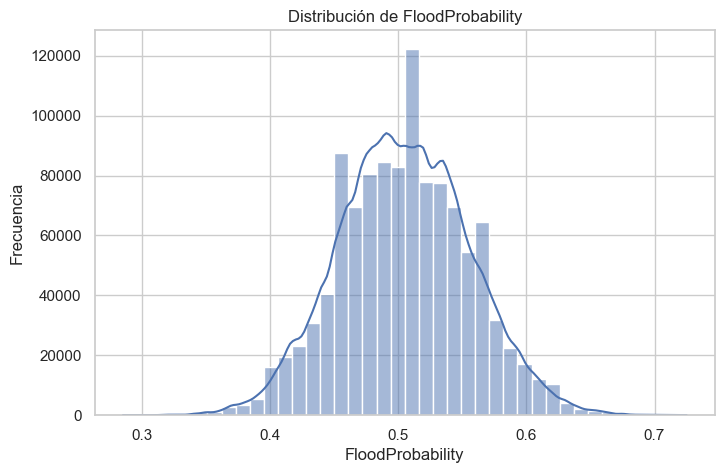

In [58]:
plt.figure(figsize=(8, 5))
sns.histplot(df[target], kde=True, bins=40)
plt.title("Distribución de FloodProbability")
plt.xlabel("FloodProbability")
plt.ylabel("Frecuencia")
plt.show()

La distribución de la variable objetivo permite comprobar cómo se reparten los valores de probabilidad de inundación y si existen concentraciones o valores extremos.

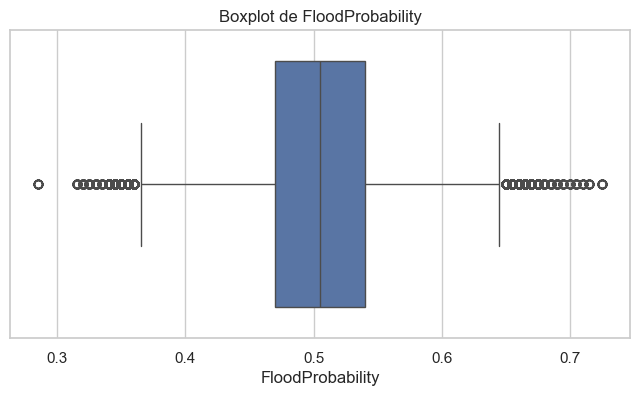

In [59]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df[target])
plt.title("Boxplot de FloodProbability")
plt.xlabel("FloodProbability")
plt.show()

El boxplot permite observar la dispersión de la variable objetivo y detectar posibles valores atípicos.

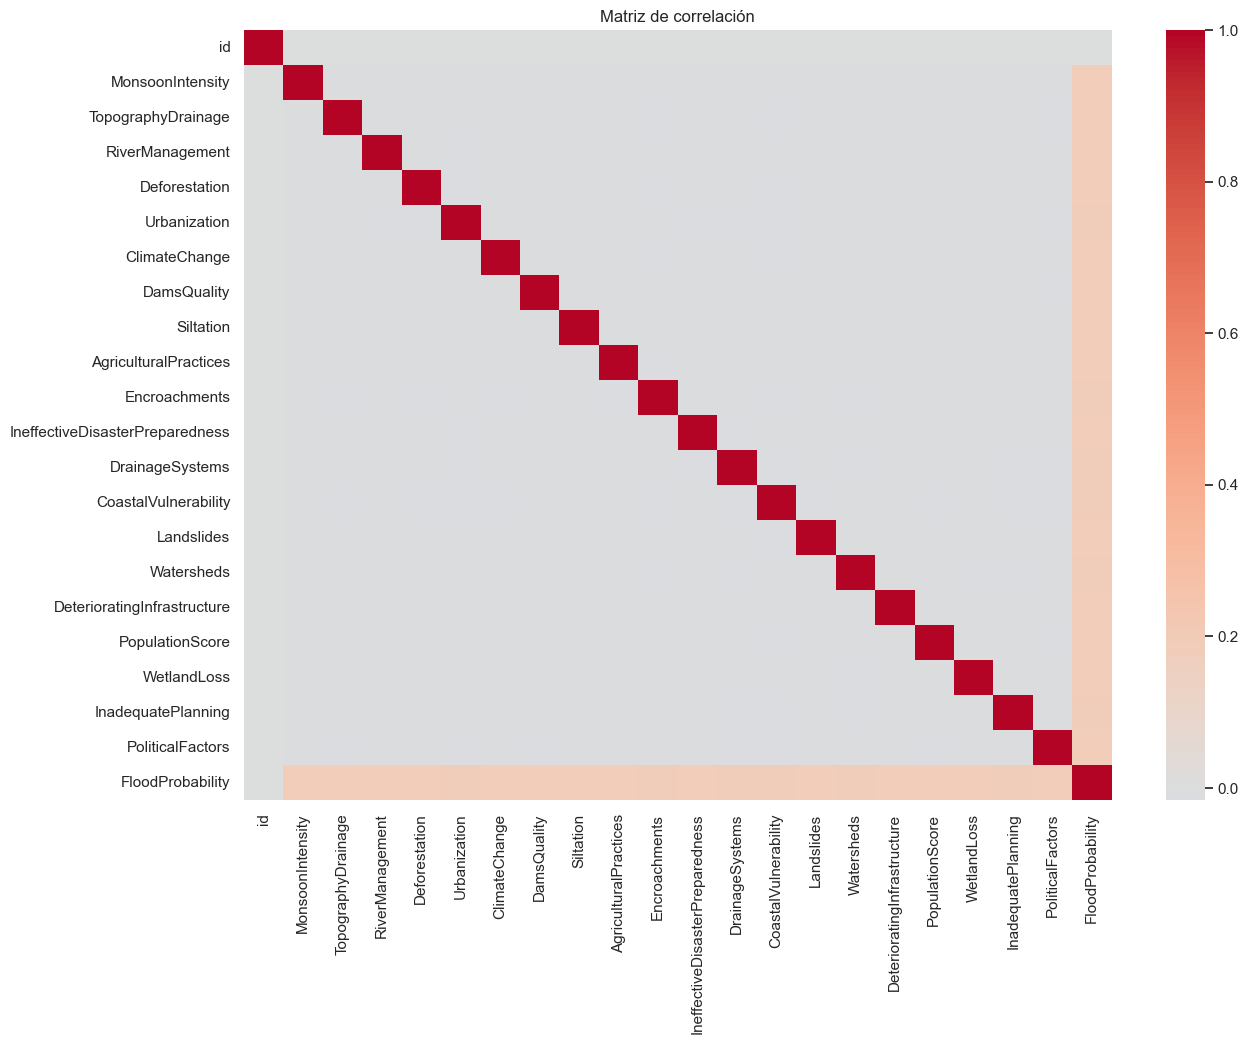

In [60]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

La matriz de correlación ayuda a identificar relaciones lineales entre las variables numéricas y la variable objetivo.

In [61]:
target_corr = corr_matrix[target].sort_values(ascending=False)
target_corr

FloodProbability                   1.000000
DeterioratingInfrastructure        0.190007
MonsoonIntensity                   0.189098
DamsQuality                        0.187996
TopographyDrainage                 0.187635
RiverManagement                    0.187131
Siltation                          0.186789
PopulationScore                    0.185890
Landslides                         0.185346
ClimateChange                      0.184761
Deforestation                      0.184001
WetlandLoss                        0.183396
AgriculturalPractices              0.183366
IneffectiveDisasterPreparedness    0.183109
PoliticalFactors                   0.182417
Watersheds                         0.181907
InadequatePlanning                 0.180968
Urbanization                       0.180861
DrainageSystems                    0.179305
Encroachments                      0.178841
CoastalVulnerability               0.177774
id                                -0.000184
Name: FloodProbability, dtype: f

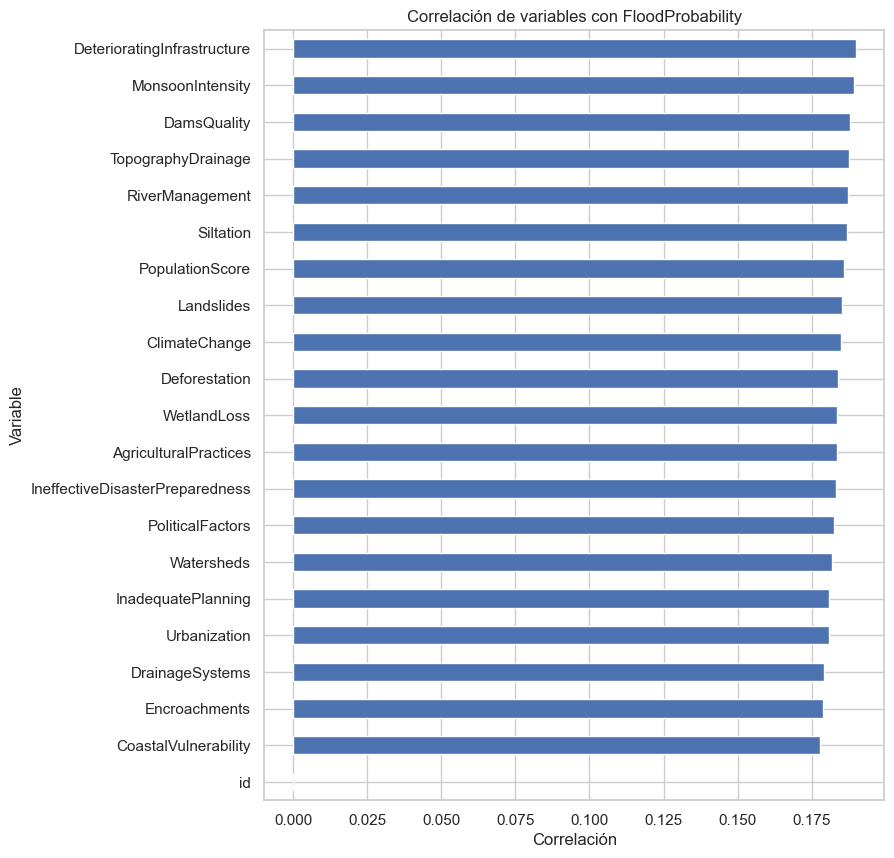

In [62]:
target_corr.drop(target).sort_values().plot(
    kind="barh",
    figsize=(8, 10),
    title="Correlación de variables con FloodProbability"
)

plt.xlabel("Correlación")
plt.ylabel("Variable")
plt.show()

Este gráfico permite identificar qué variables presentan mayor relación lineal con la probabilidad de inundación.

In [63]:
top_features = target_corr.drop(target).abs().sort_values(ascending=False).head(6).index.tolist()

top_features

['DeterioratingInfrastructure',
 'MonsoonIntensity',
 'DamsQuality',
 'TopographyDrainage',
 'RiverManagement',
 'Siltation']

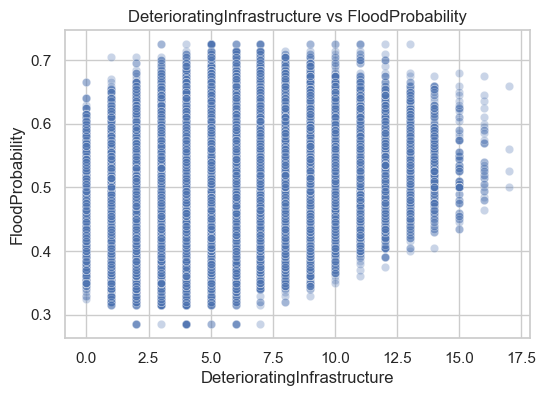

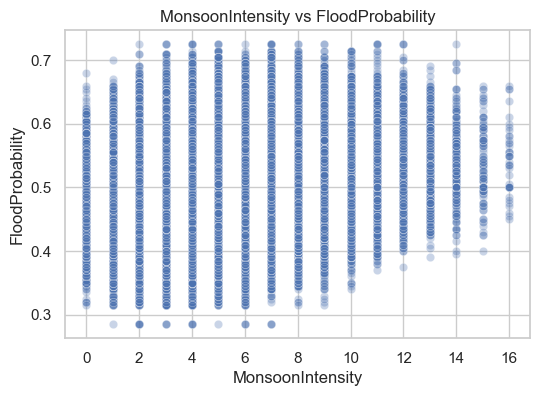

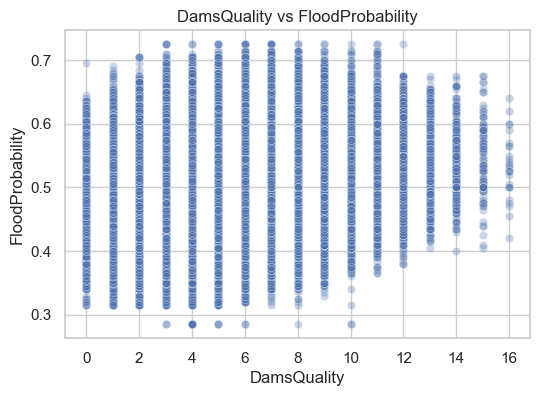

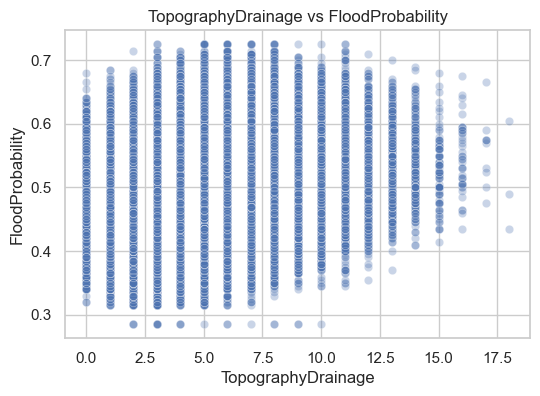

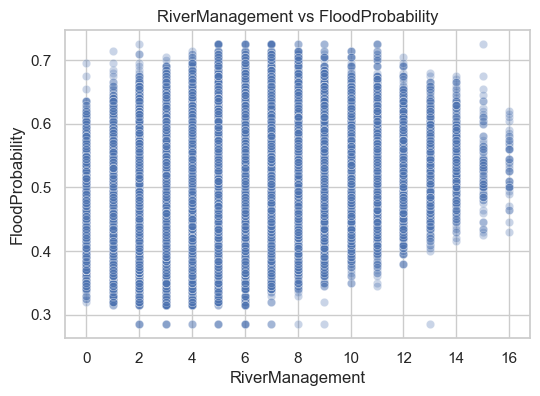

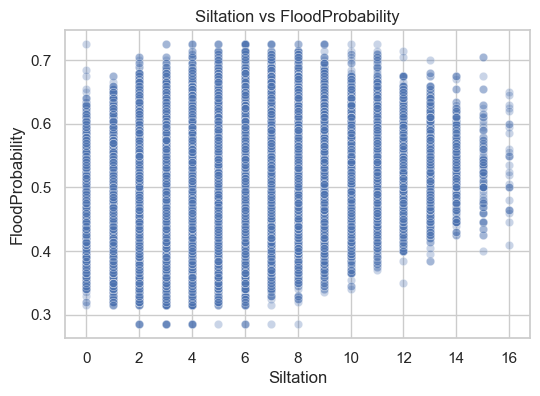

In [64]:
for col in top_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y=target, alpha=0.3)
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.show()

Los gráficos de dispersión permiten observar la relación entre las variables más correlacionadas y la variable objetivo.

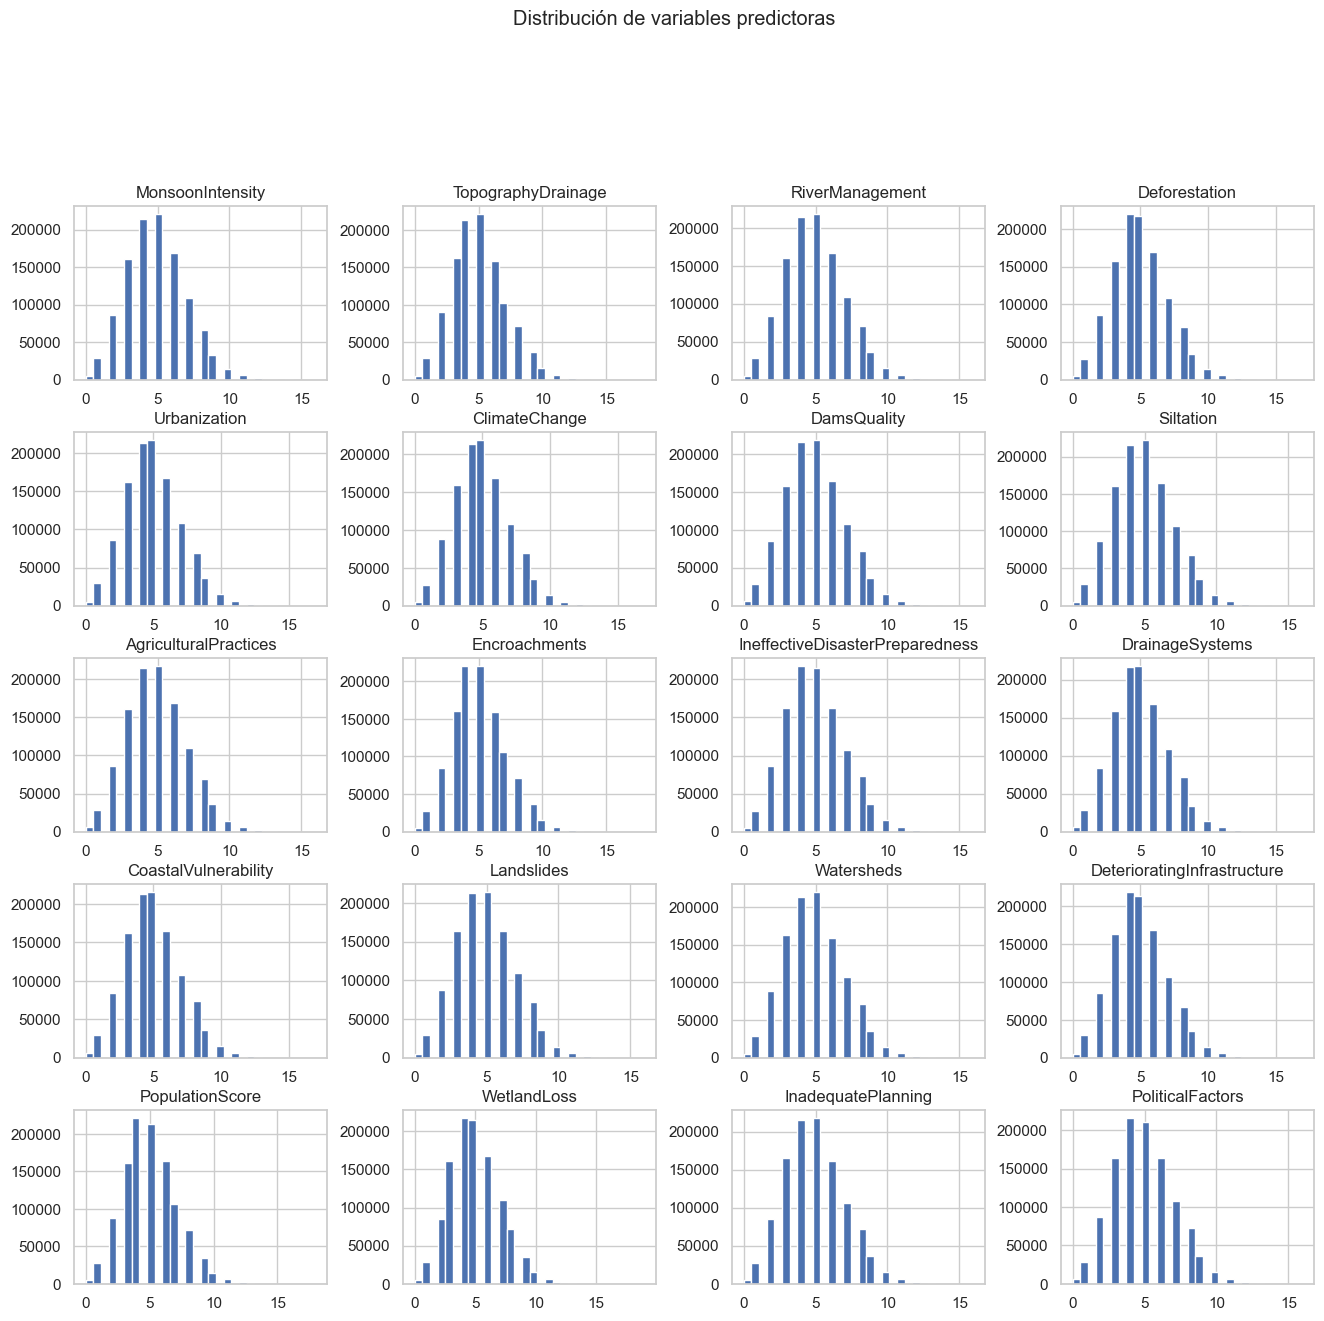

In [65]:
feature_cols = [col for col in df.columns if col not in ["id", target]]

df[feature_cols].hist(figsize=(16, 14), bins=30)
plt.suptitle("Distribución de variables predictoras", y=1.02)
plt.show()

Los histogramas permiten revisar la distribución de las variables predictoras y detectar posibles asimetrías o patrones repetidos.

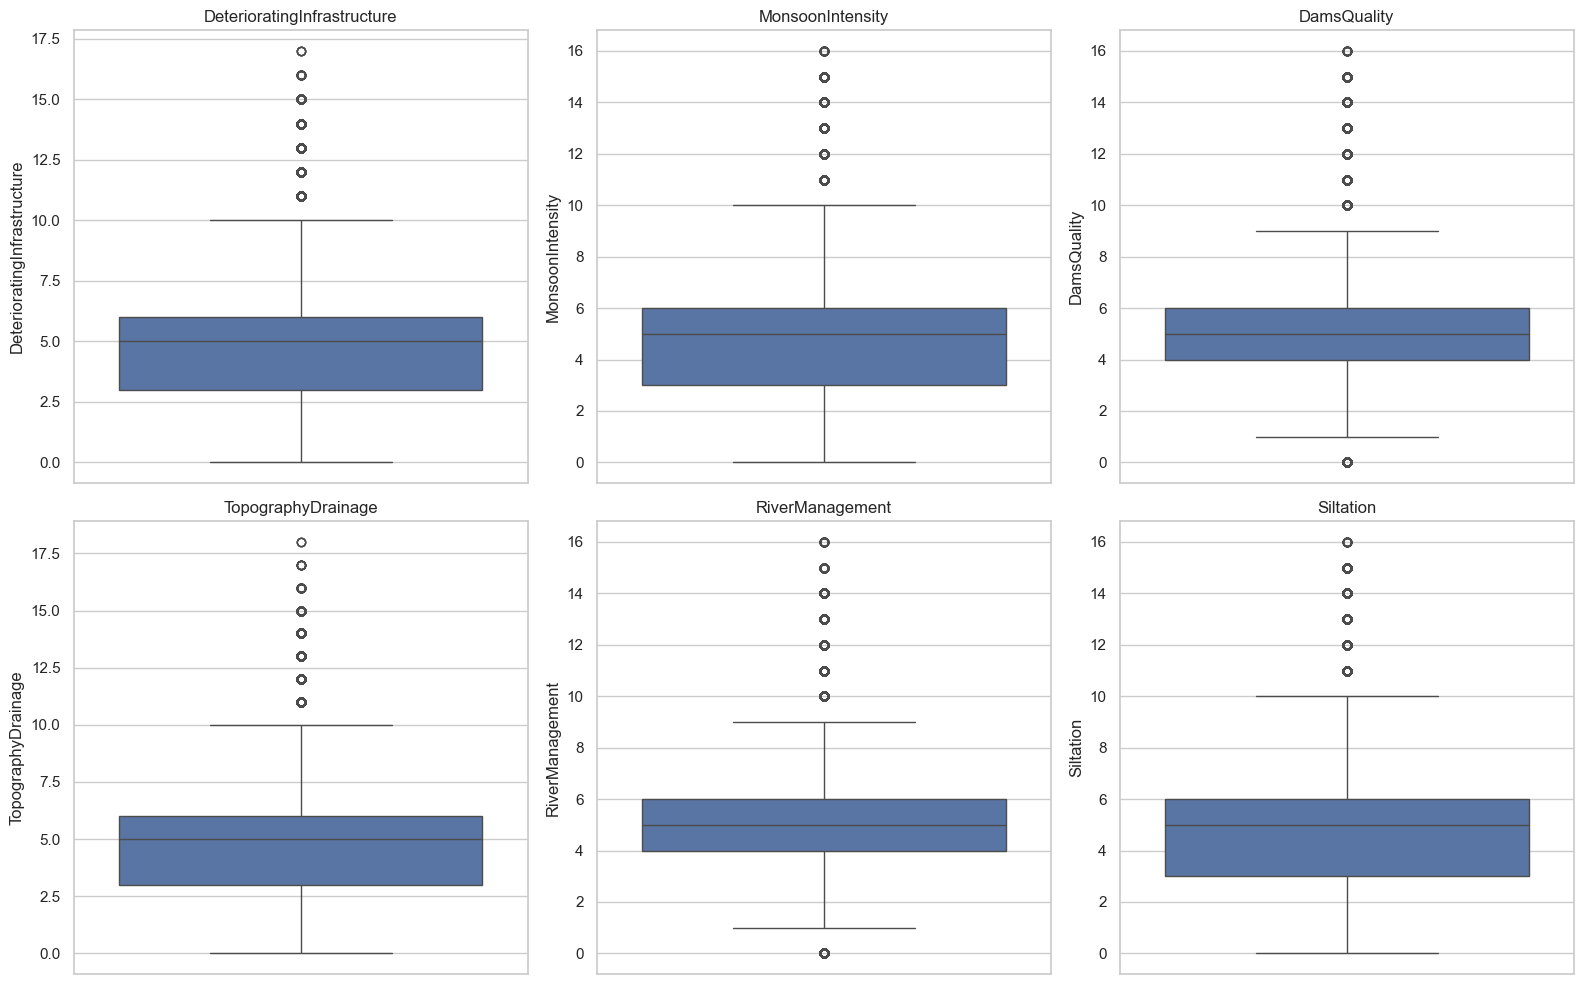

In [66]:
plt.figure(figsize=(16, 10))

for i, col in enumerate(top_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Los boxplots permiten revisar la dispersión de las variables más relevantes y detectar posibles outliers.

In [67]:
risk_features = [col for col in df.columns if col not in ["id", target]]

df["risk_score_sum"] = df[risk_features].sum(axis=1)

df[["risk_score_sum", target]].head()

,risk_score_sum,FloodProbability
0,94,0.445
1,94,0.450
2,99,0.530
3,104,0.535
4,72,0.415


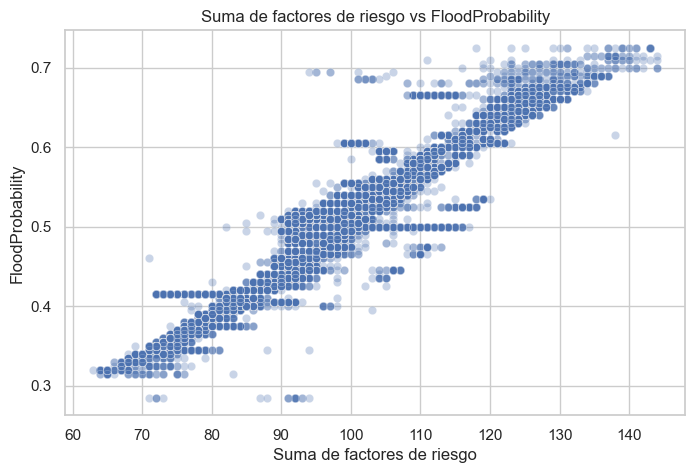

In [68]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="risk_score_sum", y=target, alpha=0.3)
plt.title("Suma de factores de riesgo vs FloodProbability")
plt.xlabel("Suma de factores de riesgo")
plt.ylabel("FloodProbability")
plt.show()

In [69]:
df[["risk_score_sum", target]].corr()

,risk_score_sum,FloodProbability
risk_score_sum,1.000000,0.919205
FloodProbability,0.919205,1.000000


La suma de factores permite observar si la acumulación de condiciones de riesgo está relacionada con una mayor probabilidad de inundación.

In [70]:
df = df.drop(columns=["risk_score_sum"])

## Conclusiones del analisis exploratorio visual

- La distribucion de `FloodProbability` se concentra alrededor de valores medios, especialmente cerca de **0,50**, sin observarse una dispersion extrema del target.
- Las variables predictoras son puntuaciones numericas relacionadas con factores de riesgo de inundacion, como intensidad del monzon, drenaje, gestion de rios, deforestacion, urbanizacion, calidad de presas o vulnerabilidad costera.
- Las correlaciones individuales con `FloodProbability` son positivas pero moderadas. Las variables mas correlacionadas son `DeterioratingInfrastructure` (**0,190**), `MonsoonIntensity` (**0,189**), `DamsQuality` (**0,188**), `TopographyDrainage` (**0,188**), `RiverManagement` (**0,187**) y `Siltation` (**0,187**).
- Ninguna variable aislada parece explicar por completo la probabilidad de inundacion. Esto sugiere que el modelo debera combinar varios factores para obtener una buena prediccion.
- La variable auxiliar `risk_score_sum`, calculada como suma exploratoria de los factores de riesgo, presenta una correlacion muy alta con `FloodProbability` (**0,919**). Esto indica que la acumulacion de factores de riesgo esta fuertemente relacionada con una mayor probabilidad de inundacion.
- La columna `id` no presenta relacion util con el target y debe excluirse del entrenamiento.
- El siguiente paso sera preparar los datos para modelado, separar `X` e `y`, eliminar `id`, crear un conjunto de validacion y entrenar un primer modelo baseline.
